# Option analytics: an ensemble that fits in one network

[`06_linear`](06_linear.ipynb) fitted a weighted sum of the option-derived features and
[`07_gbm`](07_gbm.ipynb) fitted an ensemble of trees over the same columns. This notebook fits a
third kind of model to the same rows, and the reason to fit it here is specific rather than a
general preference for neural networks. The features are what the options market was willing to
pay for a claim on what happens next, and several of them measure nearly the same thing: the
at-the-money level, its first difference, its z-score against its own year, and its percentile
all move together. A tree reaches an interaction by choosing one column at each split, so on
columns that carry almost the same information which one it chooses is close to arbitrary. A
network's first layer is a weighted sum of every feature, so it never has to choose, and the
nonlinearity after it can still combine those sums into the conditional readings of the surface
a linear model cannot write down.

**TabM is an ensemble, and the ensemble is the point.** Averaging several independently
initialized networks is the standard way to make a neural fit on a small table less erratic, and
it costs several networks. TabM trains what is nearly one. All *k* members share a single
two-layer backbone, which holds almost every parameter. What a member owns is a scaling vector
as long as the hidden layer is wide, applied element-wise to the backbone's output activations,
and its own linear output head; the *k* member predictions are then averaged. So a member is a
rescaled reading of one shared representation rather than a separate network. What each member
adds is one vector and one output layer, against a backbone of two full weight matrices, which
is why the parameter count grows slowly with `n_members` instead of multiplying by it.

**A neural fit has a meaningful state after every epoch**, in the way a boosted model has one
after every iteration and a linear fit does not. An **epoch** is one pass over the training rows.
The declared configurations train for 200 of them and save the weights every 25, so each
configuration produces eight scoreable models rather than one, and each is registered separately.
The count that matters downstream is configurations times checkpoints.

The training menus declare `tabular_dl` for the three regression labels and not for the two
`fwd_dir_*` ones, and this notebook fits every label that declares it in one run. Two folds, one
of which validates on 2020: the usable history of this dataset is short, so the walk-forward
schedule `05_evaluation` set has few and wide windows.

**Learning objectives.** By the end of this notebook you will be able to:

- Describe what a weight-sharing ensemble holds in common between its members and what it keeps
  separate, and say why *k* members cost about as much as one network.
- Read the epoch schedule out of a declared configuration and say how many scoreable models the
  run will publish for it.
- Read a curve of out-of-sample ranking accuracy against training epoch, and tell a model that is
  still learning apart from one that has started fitting the training window.
- Say why comparing configurations at their own individual best epochs is a choice made after
  seeing the answer, and where in this case study that choice is legitimately made instead.
- Say why the device a network was trained on is part of what the fitted model is.

**Book reference**: Chapter 12, Section 12.3 (Deep learning alternatives for tabular data), which
introduces TabM among the modern neural baselines. Chapter 6, Section 6.7 (Search accounting and
run logging) introduces the run log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds, and
[`06_linear`](06_linear.ipynb) and [`07_gbm`](07_gbm.ipynb) fitted the two populations this one
sits beside.

**What it writes**: one training run per configuration and one complete validation prediction set
per configuration, label and epoch checkpoint, in `run_log/registry.db` and under
`run_log/training/` and `run_log/predictions/`, grouped under a named population.
[`13_model_analysis`](13_model_analysis.ipynb) compares this family against the others, and
[`14_backtest`](14_backtest.ipynb) sweeps and selects on validation backtest Sharpe over the
primary-label members of what this notebook publishes - its sweep reads the one label
`config/setup.yaml` names primary. Its read-only evaluation section then ranks the registry
across all five labels, so the members on the other two are read there rather than nowhere.
**Selection happens there, not here.** The ranking below shows what capacity and training length
do to a ranking measure; it decides nothing.

In [1]:
"""Fit the declared option-analytics TabM population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    narrows_declared_catalog,
    open_study,
    primary_label,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""
DEVICE: str = ""

In [3]:
study = open_study(
    "sp500_equity_option_analytics",
    execution_tier=EXECUTION_TIER,
    workspace=WORKSPACE or None,
    entry_point="08_tabular_dl",
)

## 1. Which labels, and which models

The labels are the ones whose training menu declares this family, and fitting all of them in one
run is what makes this population comparable against the linear and gradient boosting ones: the
families differ, the targets do not. `fwd_ret_5d` is the stock's total return over the five
trading days after the decision date, `fwd_ret_10d` is the same over ten, and
`fwd_ret_risk_adj_5d` divides the five-day return by a measure of its own dispersion. The two
`fwd_dir_*` classification labels declare linear and gradient boosting only, so they are absent
here rather than dropped. `LABELS` restricts the run to a subset when you want one.

In [4]:
declared_labels(study, "tabular_dl")

('fwd_ret_10d', 'fwd_ret_5d', 'fwd_ret_risk_adj_5d')

Each name in the menu resolves to a preset in `case_studies/config/tabm/`. `hidden_dim` is the
width of the shared network - how many units each of its layers has - and `n_members` is how many
rescaled readings of that network are averaged together. The declared configurations step both dials
at once, so the grid asks whether a bigger and more heavily averaged model reads this surface
better; it does not separate width from ensemble size, and a difference between two rows cannot
be attributed to either. `dropout` is the fraction of units switched off at random on each
training pass, which stops the network leaning on any one of them.

`n_epochs` and `checkpoint_interval` are declared alongside the architecture rather than passed
in here, because they decide how many prediction sets each configuration owes: 200 epochs saved
every 25 is eight, and a run that quietly trained for fewer would publish a different population
under the same name.

In [5]:
configs = load_model_configs(
    study,
    "tabular_dl",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""tabular_dl""","""fwd_ret_10d""","""tabm_s""","""""","""dropout=0.1, hidden_dim=64, n_…"
"""tabular_dl""","""fwd_ret_10d""","""tabm_m""","""""","""dropout=0.1, hidden_dim=128, n…"
"""tabular_dl""","""fwd_ret_10d""","""tabm_l""","""""","""dropout=0.1, hidden_dim=256, n…"
"""tabular_dl""","""fwd_ret_5d""","""tabm_s""","""""","""dropout=0.1, hidden_dim=64, n_…"
"""tabular_dl""","""fwd_ret_5d""","""tabm_m""","""""","""dropout=0.1, hidden_dim=128, n…"
"""tabular_dl""","""fwd_ret_5d""","""tabm_l""","""""","""dropout=0.1, hidden_dim=256, n…"
"""tabular_dl""","""fwd_ret_risk_adj_5d""","""tabm_s""","""""","""dropout=0.1, hidden_dim=64, n_…"
"""tabular_dl""","""fwd_ret_risk_adj_5d""","""tabm_m""","""""","""dropout=0.1, hidden_dim=128, n…"
"""tabular_dl""","""fwd_ret_risk_adj_5d""","""tabm_l""","""""","""dropout=0.1, hidden_dim=256, n…"


`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
set of members than the canonical population does. A population is immutable once written, so
such a run must publish under its own name: on a fresh workspace it would otherwise register an
incomplete snapshot under the canonical one, and where the full population already exists the
registry refuses it. The comparison is over label-configuration pairs rather than row counts,
because two different subsets can have the same height.

The device is checked in the same cell. A network trained on a GPU and the same network trained
on a CPU accumulate their sums in different orders and reach different weights, so the device is
part of what the fitted model is and is recorded inside the computation's identity rather than
beside it. `PUBLISHED_DEVICE` is the device this population was fitted on. The runner refuses to
substitute a CPU for a requested GPU rather than publishing a different model under the published
name, so on a machine with no NVIDIA card this notebook stops at the next cell; set
`DEVICE="cpu"` and pass a `POPULATION_NAME` to fit the same grid there.

In [6]:
PUBLISHED_DEVICE = "cuda"
device = DEVICE or PUBLISHED_DEVICE
print(f"training device: {device}")

if (
    narrows_declared_catalog(study, "tabular_dl", configs) or device != PUBLISHED_DEVICE
) and not POPULATION_NAME:
    raise ValueError(
        f"this run declares {configs.height} label-configuration pairs on device {device!r}, "
        f"which is not the complete declared catalog on {PUBLISHED_DEVICE!r}, so it cannot "
        f"publish the canonical population; pass POPULATION_NAME to give it its own"
    )

training device: cuda


## 2. Binding the declarations to the data

A menu entry says which network to fit. It does not say which feature columns exist today, where
the walk-forward folds fall, or which symbol-date pairs have both a feature row and a label.
**Resolving** a request goes and finds all of that: it reads the label and feature files, computes
the fold boundaries from the walk-forward parameters in `config/setup.yaml`, and works out the
exact set of rows each fit is expected to predict.

Resolving reads the inputs and fits nothing, so the plan can be inspected before any training
starts. Four things to check in it:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row of a label.**
  They are the width of the design matrix, the number of stocks, and the number of symbol-date
  pairs to be predicted. A row that differs is a configuration measured on a different sample from
  its neighbours, and its results are not comparable with theirs. They differ *between* labels,
  because a ten-day forward window runs out earlier than a five-day one.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  `05_evaluation` established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  must not appear here: it is scored once, at the end of the case study, and any of it visible in
  this window would mean it had been used to choose something.
- **`checkpoints` is 8**, the epoch schedule declared above. Multiply it by the number of rows to
  get the number of candidate models this notebook is about to create.

Each row also carries a `training_hash`: the identity of that computation, derived from
everything that can change its result, the device included.
[`RUN_LOG.md`](../RUN_LOG.md#identity) sets out what goes into one and what follows from it.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides={"device": device},
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "label",
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,i64,i64,i64,i64,i64,date,date
"""fwd_ret_10d""","""tabm_l""",48,547,192139,2,8,2019-01-07,2020-12-16
"""fwd_ret_10d""","""tabm_m""",48,547,192139,2,8,2019-01-07,2020-12-16
"""fwd_ret_10d""","""tabm_s""",48,547,192139,2,8,2019-01-07,2020-12-16
"""fwd_ret_5d""","""tabm_l""",48,549,194813,2,8,2019-01-07,2020-12-23
"""fwd_ret_5d""","""tabm_m""",48,549,194813,2,8,2019-01-07,2020-12-23
"""fwd_ret_5d""","""tabm_s""",48,549,194813,2,8,2019-01-07,2020-12-23
"""fwd_ret_risk_adj_5d""","""tabm_l""",48,549,194748,2,8,2019-01-07,2020-12-23
"""fwd_ret_risk_adj_5d""","""tabm_m""",48,549,194748,2,8,2019-01-07,2020-12-23
"""fwd_ret_risk_adj_5d""","""tabm_s""",48,549,194748,2,8,2019-01-07,2020-12-23


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. fills missing feature values with the training window's median for that column, then
   standardizes each column to zero mean and unit variance - both fitted on the training rows only
   and then applied to the validation rows, so nothing from the validation window reaches the fit.
   A network needs this where a tree does not, twice over: a tree routes a missing value down its
   own branch while a network multiplies every input by a weight, and gradient descent on inputs
   whose scales differ by orders of magnitude takes steps far too large in one direction and far
   too small in another,
3. trains for the declared number of epochs, writing the weights to disk every 25,
4. predicts the fold's validation rows from each saved set of weights.

Step 4 is what makes one training run produce eight results. The fold predictions are concatenated
into one series per checkpoint covering the whole validation period, and each becomes its own
registered prediction set with its own identity.

Step 2 does not differ between the configurations of one label, since it depends on the data and
not on the network, but that does not by itself mean it happens once. Resolving a request stores
the panel and the fold boundaries rather than the prepared folds; the imputing and standardizing
happen later, inside the fit. So on the path this notebook takes - it resolves every request
before the call so it can show the plan above, and the runner then walks the resolved requests
one at a time - each configuration prepares its own folds from its own copy of the panel. The
path that prepares one fold set and trains every configuration of a label against it is the
batch path in `case_studies/utils/tabular_dl.py`, reached by handing `run_model_population`
unresolved requests instead. It is the one to take on a panel large enough for the repetition to
cost something, and this one is not.

**What the call publishes is a population**: a named, immutable list of the prediction sets it is
going to produce. The list is computed from the resolved specifications before the first fit and
written down, and afterwards every member must exist and be complete. That is what makes the
member set well defined: it is the 72 identities named here rather than whatever tabular_dl rows
the registry happens to hold. It is also why a configuration that raises fails the whole call
rather than publishing a population one member short. Everything that finished stays registered,
and re-running trains only what is missing.

Worth being exact about what that does and does not reach today. The population is the record of
which prediction sets this run owes and a check that it produced them. It is not yet a filter on
what the downstream notebooks read: `13_model_analysis` loads every registry metric row for the
case study and `14_backtest` loads every prediction matching its label and split, so neither is
restricted to these 72 identities. Both are being migrated to resolve the population by name, and
until they are, the guarantee this call gives is completeness rather than exclusivity.

`SUPERSEDES_POPULATION` names the population hash this run replaces, and is empty because this is
the first generation published under this name. A population is the set of prediction identities,
so anything that moves a training identity - a changed epoch schedule or device as much as a
changed configuration menu - produces a different population under the same name, and the registry
refuses to write it without being told which snapshot it supersedes. That lineage is the only
record of which generation is which.

The default name is the one the downstream notebooks will resolve, rather than a label of
convenience, which is why a run that narrows the member set or changes the device has to pass its
own instead of overwriting it.

In [8]:
population_name = POPULATION_NAME or "sp500_equity_option_analytics-tabular_dl-validation-v1"
execution, population = run_model_population(
    study,
    resolved,
    population_name=population_name,
    supersedes=SUPERSEDES_POPULATION or None,
)

reused = sum(1 for item in execution.diagnostics if item.get("reused"))
print(
    f"{len(execution.runs)} configurations: {len(execution.runs) - reused} trained, {reused} read"
)
print(f"population {population.name}: {len(population.members)} prediction sets")

Preparing and releasing folds...


  Fold 0: train=181,243  val=98,788


      epoch  25/200: loss=0.002195, IC=+0.0075


      epoch  50/200: loss=0.002087, IC=+0.0032


      epoch  75/200: loss=0.002019, IC=+0.0064


...

      epoch 200/200: loss=0.013290, IC=+0.0043


    Fold 1: best_ep=25, IC=+0.0207 (141.8s)


    → best_epoch=25, IC=+0.0106 (274.1s)



  Best: a424959cd560 @ epoch 25 (IC=+0.0106)


9 configurations: 9 trained, 0 read
population sp500_equity_option_analytics-tabular_dl-validation-v1: 72 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the registry
already holds the matching rows and the saved weights, and the runner returns the stored result
rather than training again - so re-running this notebook unchanged costs the time it takes to read
the data.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("sp500_equity_option_analytics", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "tabular_dl", labels=["fwd_ret_5d"], config_names=["tabm_s", "tabm_xl"]
)
requests = model_requests(study, configs, overrides={"device": "cuda"})
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-tabm-v1")
```

`CONFIG_NAMES` fits a subset of what the menu already declares; a name the menu does not declare
raises rather than quietly fitting fewer models than you asked for. To fit something new, add a
preset at `case_studies/config/tabm/tabm_xl.yaml` and list `tabm_xl` under `tabular_dl:` in the
label's menu. Editing an existing preset changes that configuration's identity, so its result
registers as a new row beside the old one instead of replacing it - and that includes `n_epochs`
and `checkpoint_interval`, which decide how many members the population has.

Give the run its own `population_name`: a name refers to one set of members permanently, and
reusing it for a different set raises. Everything downstream reads the registry rather than the
notebook, so predictions produced this way are selected and backtested on the same footing as the
ones shipped here, inside your workspace.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest, including how to
rehearse on a reduced universe first.

## 4. What came out

One row per label, configuration and epoch checkpoint, read back from the registry and joined to
the declared parameters so the architecture stays visible beside its result. `ic_mean` is the
**information coefficient**: on each validation date, rank the stocks by the model's prediction,
rank them by the return they went on to earn, correlate the two rankings, and average that daily
correlation over the validation period. It measures whether the model orders the cross-section
correctly, on a scale where zero is no relationship.

`ic_n_days` is how many validation dates produced a defined correlation, and it decides which rows
below are comparable with each other. A network that has settled into predicting nearly the same
value for every stock on a date gives that date no spread to rank, a constant has no rank
correlation with anything, and the date drops out of the average. Such a configuration's `ic_mean`
is then an average over the dates where it happened to stay non-degenerate, which is a different
sample from its neighbours'. `full_coverage` marks the rows measured on every date their own label
offers, and everything charted below is restricted to those.

**Coverage is judged within a label, not across them**, and so is every aggregate here. A ten-day
forward window runs out earlier than a five-day one, so one global maximum would mark a whole
label incomplete for a reason that has nothing to do with any model. A configuration name is
unique within one label's menu and not across them - all three labels declare `tabm_s` - so
grouping on the name alone would average one architecture's result across the labels it appears in
and join their learning curves end to end.

In [9]:
catalog = (
    execution.catalog_rows.select(
        "config_name",
        "label",
        "task",
        "complete",
        "checkpoint_value",
        "ic_mean",
        "ic_std",
        "ic_n_days",
        "auc_mean_daily",
        "direction_label",
        "n_folds",
        "training_hash",
        "prediction_hash",
    )
    .sort(["label", "ic_mean"], descending=[False, True])
    .join(configs.select("config_name", "label", "params"), on=["config_name", "label"], how="left")
)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("tabular_dl execution returned a partial prediction set")

catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders the panels by
# whichever label it did fit rather than by one that is not there.
panel_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
pairs = catalog.select("label", "config_name").unique().height
print(f"{catalog.height} candidate models: {pairs} label-configuration pairs")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each, on {len(panel_labels)} labels")
catalog.select(
    "label",
    "config_name",
    "params",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
).head(12)

72 candidate models: 9 label-configuration pairs
at 8 checkpoints each, on 3 labels


label,config_name,params,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,str,str,i64,f64,f64,f64,bool
"""fwd_ret_10d""","""tabm_l""","""dropout=0.1, hidden_dim=256, n…",25,0.007701,0.003037,492.0,true
"""fwd_ret_10d""","""tabm_l""","""dropout=0.1, hidden_dim=256, n…",150,0.007152,0.002244,492.0,true
"""fwd_ret_10d""","""tabm_l""","""dropout=0.1, hidden_dim=256, n…",125,0.006706,0.00159,492.0,true
"""fwd_ret_10d""","""tabm_l""","""dropout=0.1, hidden_dim=256, n…",200,0.006409,0.000598,492.0,true
"""fwd_ret_10d""","""tabm_l""","""dropout=0.1, hidden_dim=256, n…",175,0.00619,0.001,492.0,true
…,…,…,…,…,…,…,…
"""fwd_ret_10d""","""tabm_m""","""dropout=0.1, hidden_dim=128, n…",25,0.004495,0.004008,492.0,true
"""fwd_ret_10d""","""tabm_l""","""dropout=0.1, hidden_dim=256, n…",100,0.003371,0.004262,492.0,true
"""fwd_ret_10d""","""tabm_s""","""dropout=0.1, hidden_dim=64, n_…",175,0.002649,0.005891,492.0,true


### What the grid does on each label

The frame below is the comparison this notebook can make only because every label declaring the
family was fitted in one run. The features are the same and the folds are the same throughout, and
the three labels share one menu, so down these rows the only thing that changes is what is being
predicted.

`ic_mean` is defined for every row, which is what puts every label on one axis. `auc_mean_daily`
can be too, and `direction_label` says what it was scored against: a regression row has no classes
of its own and is scored as a ranking signal against a declared direction sibling - `fwd_ret_5d`
against `fwd_dir_5d`, `fwd_ret_10d` against `fwd_dir_10d`. The AUC is computed against that
sibling label's values, not against any sibling model's predictions, and those siblings are fitted
in [`06_linear`](06_linear.ipynb) and [`07_gbm`](07_gbm.ipynb) rather than here.
`fwd_ret_risk_adj_5d` declares no sibling and carries no AUC; null there means not computed, not
zero.

In [10]:
by_label = (
    catalog.filter("full_coverage")
    .group_by("label")
    .agg(
        task=pl.col("task").first(),
        configurations=pl.col("config_name").n_unique(),
        candidates=pl.len(),
        scored_dates=pl.col("ic_n_days").max(),
        best_ic=pl.col("ic_mean").max(),
        worst_ic=pl.col("ic_mean").min(),
        n_positive=(pl.col("ic_mean") > 0).sum(),
        best_auc_daily=pl.col("auc_mean_daily").max(),
        auc_scored_against=pl.col("direction_label").drop_nulls().first(),
    )
    .sort("best_ic", descending=True)
)
by_label

label,task,configurations,candidates,scored_dates,best_ic,worst_ic,n_positive,best_auc_daily,auc_scored_against
str,str,u32,u32,f64,f64,f64,u32,f64,str
"""fwd_ret_risk_adj_5d""","""regression""",3,24,497.0,0.014247,-0.000292,23,null,null
"""fwd_ret_5d""","""regression""",3,24,497.0,0.009793,0.000389,24,0.504016,"""fwd_dir_5d"""
"""fwd_ret_10d""","""regression""",3,24,492.0,0.007701,-0.005855,19,0.502886,"""fwd_dir_10d"""


### What more training does

Each line traces one configuration's out-of-sample IC as epochs are added to it, in its own
label's panel. This is the figure the checkpoint dimension exists to produce, and it separates two
things a single end-of-training number cannot.

A line that rises and then falls has an interior optimum: the network was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
around zero without trend never had anything to learn in the first place, and its highest point is
wherever the noise happened to peak. Both produce a respectable-looking maximum, which is why the
maximum is not what a configuration is judged on.

The panels share one vertical scale. Stacking them is what makes the labels comparable, and
rescaling each to fill its own row would make three different spreads look alike.

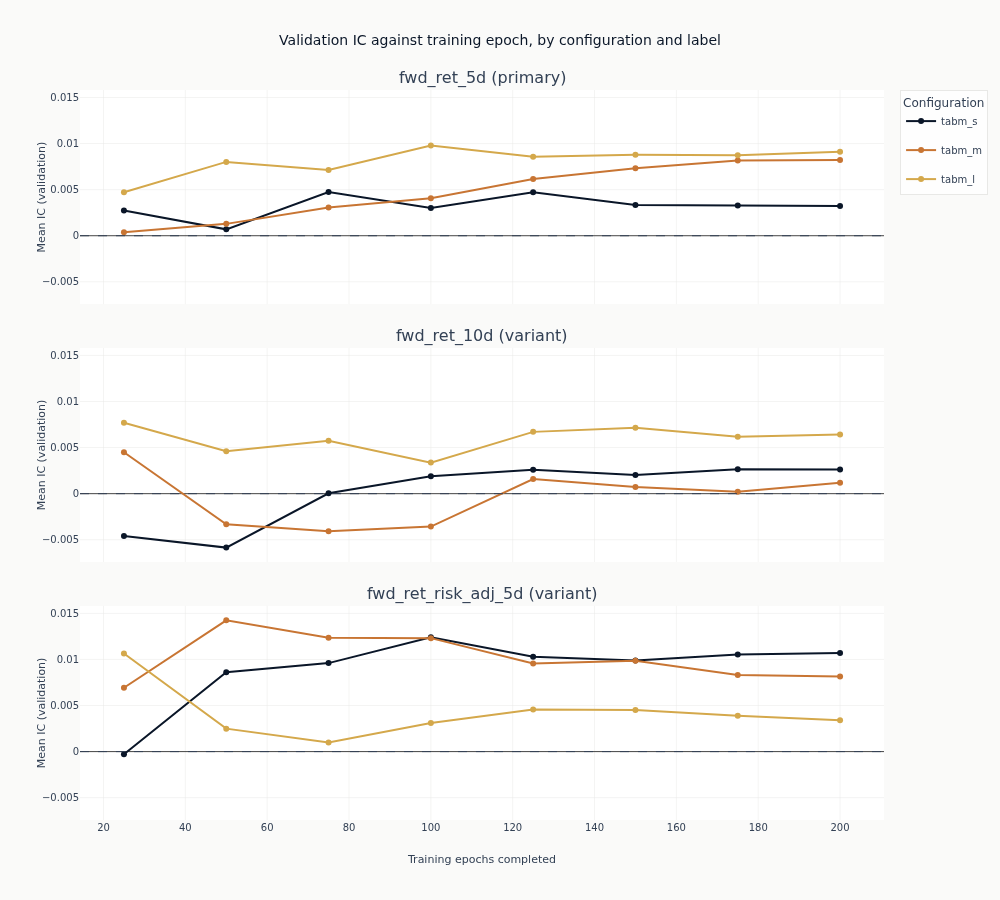

In [11]:
curves = catalog.filter("full_coverage").sort("label", "config_name", "checkpoint_value")
charted = set(curves.get_column("config_name"))
# Menu order, which is the order the frame in section 1 showed and the order the presets step
# capacity in. Sorting on the formatted parameter string instead would order 128 before 64.
config_order = [
    name
    for name in configs.get_column("config_name").unique(maintain_order=True)
    if name in charted
]
# One colour per configuration, so the same configuration keeps its colour in both figures. A
# fourth configuration needs a fourth colour rather than a wrapped palette that would give two of
# them the same swatch and make them read as one.
line_colors = [COLORS["blue"], COLORS["copper"], COLORS["amber"], COLORS["positive"]]
if len(config_order) > len(line_colors):
    raise ValueError(
        f"{len(config_order)} configurations against {len(line_colors)} distinct line colours; "
        "add colours rather than letting two configurations share one"
    )
color_of = dict(zip(config_order, line_colors, strict=False))

fig_curves = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.06,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = curves.filter(pl.col("label") == label)
    for config_name in config_order:
        series = panel.filter(pl.col("config_name") == config_name).sort("checkpoint_value")
        if not series.height:
            continue
        fig_curves.add_trace(
            go.Scatter(
                x=series.get_column("checkpoint_value").to_list(),
                y=series.get_column("ic_mean").to_list(),
                mode="lines+markers",
                name=config_name,
                legendgroup=config_name,
                showlegend=row == 1,
                line=dict(color=color_of[config_name], width=2),
                marker=dict(size=6, color=color_of[config_name]),
            ),
            row=row,
            col=1,
        )
    fig_curves.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_curves.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
    # `shared_yaxes` matches axes across columns, so with one column it does nothing. Matching
    # every row to the first is what puts the labels on one vertical scale.
    if row > 1:
        fig_curves.update_yaxes(matches="y", row=row, col=1)
fig_curves.update_xaxes(title_text="Training epochs completed", row=len(panel_labels), col=1)
fig_curves.update_layout(
    title="Validation IC against training epoch, by configuration and label",
    height=300 * len(panel_labels),
    width=1000,
    margin=dict(t=90),
    legend=dict(title_text="Configuration"),
)
# The span of each panel and how many of its lines cross zero are facts about the frame, so the
# description reads them rather than asserting a shape the next run may not have.
panel_facts = {
    row["label"]: row
    for row in curves.group_by("label")
    .agg(
        lowest=pl.col("ic_mean").min(),
        highest=pl.col("ic_mean").max(),
        total=pl.col("config_name").n_unique(),
        below=pl.col("config_name").filter(pl.col("ic_mean") < 0).n_unique(),
    )
    .to_dicts()
}
panel_text = ". ".join(
    "The {} panel spans {:+.3f} to {:+.3f}, with {} of its {} lines dipping below zero at some "
    "checkpoint".format(
        label,
        panel_facts[label]["lowest"],
        panel_facts[label]["highest"],
        panel_facts[label]["below"],
        panel_facts[label]["total"],
    )
    for label in panel_labels
)
show_plotly_with_alt(
    fig_curves,
    "Line charts of mean validation information coefficient against the number of training epochs "
    "completed, one line per configuration in dark navy, copper and gold, with a marker at each "
    "saved checkpoint. One panel per label, sharing one vertical scale, each with a dashed zero "
    f"line. {panel_text}.",
)

### Comparing the configurations at the same training length

The chart below drops the checkpoint dimension by taking each configuration's final state, so all
of them are compared at the same amount of training. That is the comparison that requires choosing
nothing after the fact, and it is the one the grid was built to make: whether a wider network
carrying more ensemble members reads this surface better. The configurations are in the same order
in every panel, the order the menu declares them in, which steps width and member count up
together - so a panel that slopes in one direction is a label where capacity moved the ranking
measure, and one that does not is a label where it did not.

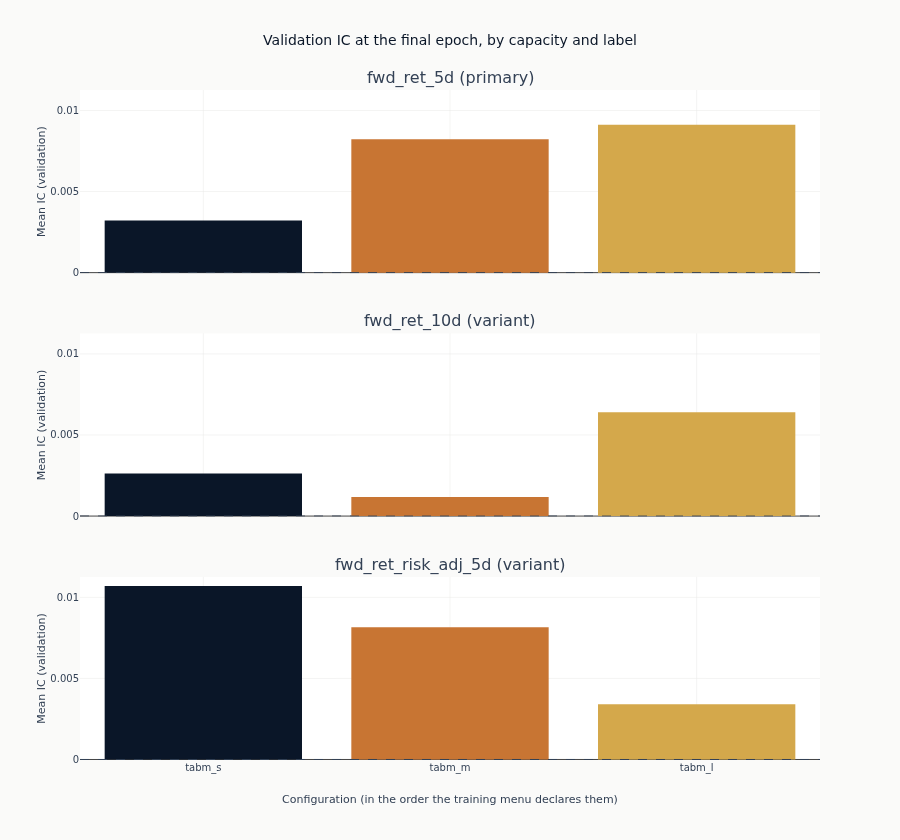

In [12]:
final = (
    catalog.filter(pl.col("checkpoint_value") == pl.col("checkpoint_value").max().over("label"))
    .filter("full_coverage")
    .sort("label", "config_name")
)

fig_capacity = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.09,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = final.filter(pl.col("label") == label)
    fig_capacity.add_trace(
        go.Bar(
            x=panel.get_column("config_name").to_list(),
            y=panel.get_column("ic_mean").to_list(),
            marker_color=[color_of[name] for name in panel.get_column("config_name")],
        ),
        row=row,
        col=1,
    )
    fig_capacity.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_capacity.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
    if row > 1:
        fig_capacity.update_yaxes(matches="y", row=row, col=1)
fig_capacity.update_xaxes(
    categoryorder="array",
    categoryarray=config_order,
    title_text="Configuration (in the order the training menu declares them)",
    row=len(panel_labels),
    col=1,
)
fig_capacity.update_layout(
    title="Validation IC at the final epoch, by capacity and label",
    height=280 * len(panel_labels),
    width=900,
    showlegend=False,
    margin=dict(t=90),
)
capacity_text = ". ".join(
    "The {} panel runs from {:+.3f} to {:+.3f} with {} of {} bars above zero".format(
        label,
        final.filter(pl.col("label") == label).get_column("ic_mean").min(),
        final.filter(pl.col("label") == label).get_column("ic_mean").max(),
        final.filter((pl.col("label") == label) & (pl.col("ic_mean") > 0)).height,
        final.filter(pl.col("label") == label).height,
    )
    for label in panel_labels
)
show_plotly_with_alt(
    fig_capacity,
    "Bar charts of mean validation information coefficient at the final training epoch, one bar per "
    "configuration in menu order and coloured as in the previous figure. One panel per label on one "
    f"shared vertical scale, each with a dashed zero line. {capacity_text}.",
)

### How far the epoch count moves a configuration

The two figures above measure two different things, and this frame puts them on one scale.
`across_configs` is the IC range over the configurations at the final epoch, which is what the
capacity chart shows. `median_within_config` is the median range a single configuration covers
over its own eight checkpoints, which is what the curves show. When the second is the larger, the
stopping point moves the ranking measure further than the architecture does, and reporting each
configuration's own best checkpoint would be reporting the maximum of eight draws as though it
were one. Both quantities are computed inside a label, because a within-run range compared against
a spread taken across labels would compare two different things.

In [13]:
spread = (
    curves.group_by("label", "config_name")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_final=pl.col("ic_mean").sort_by("checkpoint_value").last(),
        peak_checkpoint=pl.col("checkpoint_value").sort_by("ic_mean", descending=True).first(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .sort(["label", "config_name"])
)
epoch_against_capacity = (
    spread.group_by("label")
    .agg(
        configurations=pl.len(),
        across_configs=pl.col("ic_final").max() - pl.col("ic_final").min(),
        median_within_config=pl.col("checkpoint_range").median(),
    )
    .with_columns(checkpoint_dominates=pl.col("median_within_config") > pl.col("across_configs"))
    .sort("label")
)
epoch_against_capacity

label,configurations,across_configs,median_within_config,checkpoint_dominates
str,u32,f64,f64,bool
"""fwd_ret_10d""",3,0.005232,0.008504,true
"""fwd_ret_5d""",3,0.005906,0.005074,false
"""fwd_ret_risk_adj_5d""",3,0.007296,0.009675,true


## 5. What to notice

**An epoch checkpoint is part of the configuration, not a detail of how it was fitted.** Three
declared configurations at eight checkpoints each are 24 candidate models per label, and
`epoch_against_capacity` is how you tell whether that distinction is doing work: compare the
spread a single configuration covers over its own training run against the spread across the
configurations at a fixed training length. Where the first is comparable to the second, a stopping
point chosen after seeing the curves would be doing about as much of the ranking as the choice of
architecture. That is why every checkpoint is registered as its own prediction set rather than each
configuration reporting its own best one. A network is more exposed to this than the boosted grid
in [`07_gbm`](07_gbm.ipynb) was, because adding trees always adds capacity while an additional
epoch can move the weights in either direction.

**Read the ranking with the coverage column or it will mislead you.** A network that has settled
into predicting nearly the same value for every stock contributes no rank correlation on those
dates, and its IC is then an average over the dates where it stayed non-degenerate. `ic_n_days` is
what makes that visible, and it is the same failure mode the most aggressive L1 settings produced
in [`06_linear`](06_linear.ipynb) by a different mechanism. A metric averaged over a set the model
itself selected is not a metric.

**Capacity is not a dial you turn up.** The grid steps width and ensemble size together across a
factor of four, on two folds of a short history. A larger network has more ways to describe the
training window exactly, and there is not much more structure here for it to find, so the useful
thing to read from the capacity chart is whether the ranking measure moves at all rather than
which end of the grid leads. Separating width from ensemble size needs a grid that crosses them,
which is a different experiment from the one declared.

**These features forecast dispersion rather than direction, and the label set tests it.** Implied
volatility says how wide the market expects the distribution to be, skew how asymmetric, the term
structure how that changes with horizon, the variance risk premium how much the market charges for
bearing it. None is a claim about the *mean*, which is what a forward return is. A risk-adjusted
return divides that mean by a measure of width, so a feature set that forecasts width well should
rank it better than the raw return. `by_label` is where that prediction meets the evidence, and it
is the same comparison [`06_linear`](06_linear.ipynb) and [`07_gbm`](07_gbm.ipynb) make, so a
reading that holds across three model families is about the target rather than any one of them.

**The device is part of the model.** Two runs of the same configuration on a GPU and a CPU sum
their gradients in different orders and end at different weights, which is why the device sits
inside the training identity and why a run on another device publishes under its own population
name. That is not a formality: a population is the set of prediction identities the backtest
selects over, and two devices produce two sets.

**None of this selects anything.** IC measures whether predictions order the cross-section
correctly, not whether a strategy trading them makes money after costs and turnover. Those are
different questions and a configuration can lead on the first while losing on the second.
Selection is on validation backtest Sharpe over the population this notebook just published, and
it happens in [`14_backtest`](14_backtest.ipynb), where the checkpoint is part of what is
selected.

**Known limitations.** Two folds, one of them 2020, a year in which the option surface behaved
unlike any other in the sample. The IC is an average of daily rank correlations with no adjustment
for the serial dependence that overlapping multi-day returns create, so it is a ranking diagnostic
rather than a test, and it carries no interval that would say whether these configurations differ
from each other or from the linear and boosted ones. The grid moves width and ensemble size
together at a fixed dropout, learning rate and batch size. The checkpoint schedule searches
training lengths in steps of 25 epochs up to 200 and says nothing about what happens outside that
range. And every number here is measured on validation folds already read many times over by the
time a case study reaches this notebook.

**Next**: [`09_dl_lstm`](09_dl_lstm.ipynb) stops treating each decision date as an independent row
and feeds the network the recent history of each stock as a sequence, which is the one thing none
of the three families so far can see. [`10_dl_patchtst`](10_dl_patchtst.ipynb) asks the same
question with a transformer, and [`11_latent_factors`](11_latent_factors.ipynb) asks whether the
surface has structure that a supervised model is the wrong instrument for.